In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from probeinterface import get_probe, write_probeinterface

from format_waveform_data import map_contacts_to_intan

In [2]:
''' File Paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "LMN88"
session_id = "260722"
cmr = False

# ephys IDs for the sessions to concatenate, in chronological order
ephys_ids = [
    "LMN88_260722_110459",
    "LMN88_260722_115951",
]

# path to .rhd intan files
intan_folders = [f"{root_dir}{bird_id}_{session_id}/{eid}/" for eid in ephys_ids]

# behavior video start and end samples
behavior_folder = f"{root_dir}{bird_id}_{session_id}/behavior_data/"
vid_start_samples = np.load(f"{behavior_folder}vid_starts.npy")
vid_end_samples = np.load(f"{behavior_folder}vid_ends.npy")

# probe map
map_file_path = "Z:/Isabel/ephys/channel_maps/SILICON PROBE MAP H5_spikesort.xlsx"

# to save files -- one combined output dir for the concatenated recording
save_dir = f"{root_dir}{bird_id}_{session_id}/{bird_id}_{session_id}_concat/"
os.makedirs(save_dir, exist_ok=True)
sort_dir = f"{save_dir}/kilosort4_bc/"

In [3]:
''' get the probe layout '''
probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-236-H5")
contact_sort, ch_names, shank_idx = map_contacts_to_intan(probe, map_file_path)

In [11]:
''' load the recordings and double-check compatibility '''
recordings = []
for i_sess, folder in enumerate(intan_folders):
    # load the recording
    rec = se.read_intan(f"{folder}info.rhd", stream_id='0')

    # crop to the behavioral video start/end
    start_frame = int(vid_start_samples[i_sess][0]) - 1
    end_frame = int(vid_end_samples[i_sess][0])
    rec = rec.frame_slice(start_frame=start_frame, end_frame=end_frame)

    # save to concatenate
    recordings.append(rec)

fs = recordings[0].get_sampling_frequency()
assert all(r.get_sampling_frequency() == fs for r in recordings), \
    "sessions have different sample rates -- can't concatenate directly"
assert all(np.array_equal(r.channel_ids, recordings[0].channel_ids) for r in recordings), \
    "sessions have different channel sets -- can't concatenate directly"

In [12]:
# number of raw samples in each session, in order
n_samples_per_session = [r.get_num_samples() for r in recordings]
np.save(f"{save_dir}n_samples_per_session.npy", np.array(n_samples_per_session))
print(f"samples per session: {n_samples_per_session}")
print(f"mins per session: {np.asarray(n_samples_per_session)/fs/60}")

samples per session: [93012592, 153542821]
mins per session: [51.67366222 85.30156722]


In [13]:
''' concatenate the sessions '''
recording = si.concatenate_recordings(recordings)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

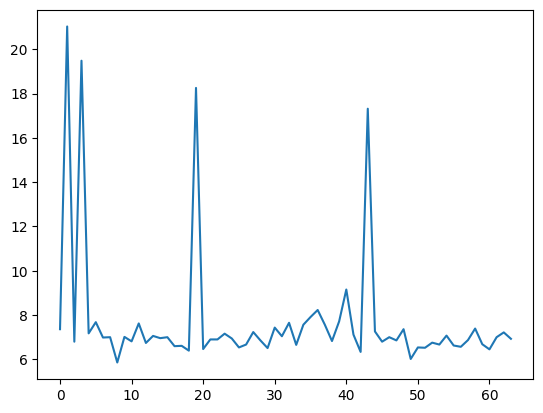

In [14]:
''' find and exclude noisy channels '''
noise_level = si.get_noise_levels(spre.common_reference(spre.highpass_filter(recording)))
plt.plot(noise_level)

In [15]:
# set noise threshold and remove noisy channels
n_channels = len(ch_names)
all_ch_idx = np.arange(n_channels)
noise_thresh = 16
keep_ch_idx = noise_level < noise_thresh
bad_channel_idx = all_ch_idx[~keep_ch_idx]
print(f"excluding {np.sum(~keep_ch_idx)} channel(s): "
      f"{recording.channel_ids[bad_channel_idx]}")

excluding 4 channel(s): ['A-001' 'A-003' 'A-019' 'A-043']


In [16]:
# check the gain
gains = recording.get_channel_gains()
assert np.allclose(gains, gains[0]), "expected uniform gain across channels"
gain_to_uV = float(gains[0])   # typically 0.195 for Intan RHD-based systems

In [17]:
# common median reference if needed
if cmr:
    rec_cmr = spre.common_reference(recording, reference="global", operator="median")
else:
    rec_cmr = recording

In [19]:
# save as binary for KS4 and BC
rec_cmr.save(format="binary", folder=sort_dir, dtype="int16", 
             n_jobs=8, chunk_duration="1s")

write_binary_recording 
engine=process - n_jobs=8 - samples_per_chunk=30,000 - chunk_memory=3.66 MiB - total_memory=29.30 MiB - chunk_duration=1.00s


write_binary_recording (workers: 8 processes spawn):   0%|          | 0/8219 [00:00<?, ?it/s]

BinaryFolderRecording: 64 channels - 30.0kHz - 1 segments - 246,555,413 samples 
                       8,218.51s (2.28 hours) - int16 dtype - 29.39 GiB

In [21]:
bad_channel_string = ''
for b_idx in bad_channel_idx:
    bad_channel_string = bad_channel_string + f'{b_idx}, '

print(f"Binary ready for native Kilosort4 GUI: {sort_dir}/traces_cached_seg0.raw")
print(f"Channel index to exlude: [{bad_channel_string}], fs: {fs}, gain_to_uV: {gain_to_uV}")

Binary ready for native Kilosort4 GUI: C:/Users/Isabel/Documents/data_temp/LMN88_260722/LMN88_260722_concat//kilosort4_bc//traces_cached_seg0.raw
Channel index to exlude: [1, 3, 19, 43, ], fs: 30000.0, gain_to_uV: 0.195
